# 🕵️‍♂️ The Quantum Heist: Breaking RSA (Manual Circuit Edition)
**Event:** QCoffee Hangout (Tripoli University)  
**Facilitator:** Abdulmalek Baitulmal  
**Version:** V2 (Qiskit 1.x Native)

---

### 📜 Mission Briefing
You are the **Red Team**. You have intercepted a secure banking transmission.
The target is using **RSA-1024** (simulated as RSA-15 for this workshop).

**The Problem:** The standard "Shor's Algorithm" automated software is offline.
**The Solution:** We must manually configure the quantum gates to break the key.

**Objectives:**
1. Intercept the Public Key ($N$).
2. Build a Quantum Circuit to find the period of $a^x \pmod N$.
3. Use the period to calculate the factors ($p, q$).
4. Decrypt the message.

In [1]:
# @title 🛠️ Phase 0: Equip Tools
# Installing Core Qiskit and Aer Simulator (No external algorithms library needed)
!pip install qiskit qiskit-aer pylatexenc matplotlib cryptography

import numpy as np
import matplotlib.pyplot as plt
from math import gcd

# Qiskit Imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("✅ Quantum Uplink Established.")


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
✅ Quantum Uplink Established.


## 📡 Phase 1: The Interception

We have captured a handshake packet. 
The server provided a **Public Key ($N$)**.

For this simulation, $N = 15$.

In [9]:
# --- TARGET PARAMETERS ---
N = 15      # The Public Key to break
e = 7       # The Exponent
a = 7       # The 'Guess' number we use in Shor's algorithm

print(f"🎯 TARGET ACQUIRED")
print(f"------------------")
print(f"Public Key (N): {N}")
print(f"Mathematical Challenge: Find p, q such that p * q = {N}")

🎯 TARGET ACQUIRED
------------------
Public Key (N): 15
Mathematical Challenge: Find p, q such that p * q = 15


## 📦 Phase 2: The Locked Payload

We also have the encrypted message. It looks like nonsense right now.

In [15]:
# --- ENCRYPTED DATA ---
secret_flag_int =2  # The hidden message

# Encryption: C = M^e mod N
encrypted_msg = (secret_flag_int ** e) % N

print(f"🔒 ENCRYPTED MESSAGE: {encrypted_msg}")
print("To unlock this, we need the Private Key. We need factors of N.")

🔒 ENCRYPTED MESSAGE: 8
To unlock this, we need the Private Key. We need factors of N.


## ⚛️ Phase 3: The Manual Quantum Attack

Since we cannot use the automated library, we will **build the circuit architecture** ourselves.

**The Architecture:**
1.  **Counting Qubits (Top 3):** To measure the phase.
2.  **Work Qubits (Bottom 4):** To perform the calculation $7^x \pmod{15}$.
3.  **QFT Inverse:** To translate the quantum waves into a readable number.

Let's assemble the circuit.

Circuit Design Complete. Visualizing...


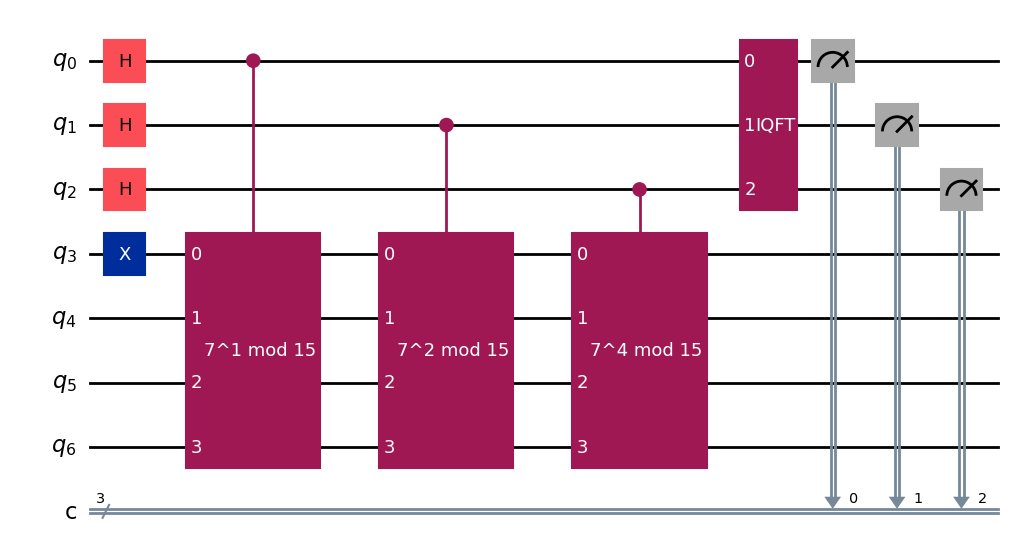

In [39]:
# --- BUILDING THE QUANTUM CIRCUIT ---

def c_amod15(power):
    """Controlled multiplication by 7^power mod 15"""
    if power == 0: return QuantumCircuit(4)
    U = QuantumCircuit(4)
    # This is a specific optimized gate for 7^x mod 15
    # It essentially swaps states to mimic modular exponentiation
    for _ in range(power):
        U.swap(2, 3)
        U.swap(1, 2)
        U.swap(0, 1)
        for q in range(4):
            U.x(q)
    U = U.to_gate()
    U.name = f"7^{power} mod 15"
    c_U = U.control()
    return c_U

# 1. Initialize Registers
n_count = 3  # 3 qubits for precision
qc = QuantumCircuit(n_count + 4, n_count)

# 2. Initialize State
qc.h(range(n_count)) # Superposition on counting qubits
qc.x(n_count)        # Set work register to |1> (required for Shor's)

# 3. Apply Controlled-U Operations
for q in range(n_count):
    qc.append(c_amod15(2**q), [q] + list(range(n_count, n_count+4)))

# 4. Inverse QFT
qc.append(QFT(n_count, inverse=True), range(n_count))

# 5. Measure
qc.measure(range(n_count), range(n_count))

# Draw the circuit (Optional: Remove if it takes too much space)
print("Circuit Design Complete. Visualizing...")
qc.draw('mpl')

🚀 RUNNING SIMULATION ON LOCAL CPU...


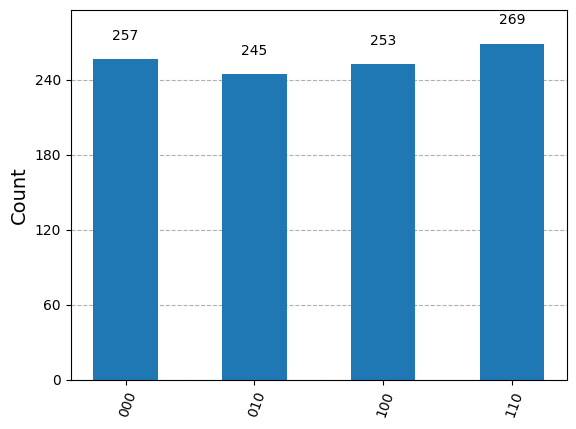

In [48]:
# --- EXECUTION ---
print(f"🚀 RUNNING SIMULATION ON LOCAL CPU...")

backend = AerSimulator()
transpiled_qc = transpile(qc, backend)
counts = backend.run(transpiled_qc, shots=1024).result().get_counts()

plot_histogram(counts)


## 📊 Phase 4: Analysis & Decryption

The histogram shows peaks. We need to convert these quantum measurements into our factors ($p$ and $q$).

In [49]:
# --- POST-PROCESSING & ANALYSIS ---
from fractions import Fraction

print(f"📊 ANALYZING QUANTUM MEASUREMENTS...")

# 1. Get the most likely measurement (The highest peak)
# We sort the counts to find the most probable state
sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
top_measurement_str = sorted_counts[0][0]
measured_int = int(top_measurement_str, 2)

print(f"Dominant Quantum State: |{top_measurement_str}> (Integer: {measured_int})")

# 2. Convert State to Phase
# Formula: Phase = measured_value / 2^(number_of_qubits)
n_count = 3  # We used 3 counting qubits
phase = measured_int / (2**n_count)
print(f"Calculated Quantum Phase: {phase}")

# 3. AUTOMATIC PERIOD FINDING (Continued Fractions)
# We use Python to find the denominator 'r' that creates this phase.
# We limit the denominator to N because the period cannot be larger than N.
frac = Fraction(phase).limit_denominator(N)
r = frac.denominator

print(f"Derived Fraction: {frac.numerator}/{frac.denominator}")
print(f"Detected Period (r): {r}")

# 4. Check if 'r' is valid
if r % 2 != 0:
    print("⚠️ Period 'r' is odd. Shor's algorithm requires an even period. Retrying with r*2...")
    r = r * 2  # Heuristic fix for certain cases

# 5. Calculate Factors
# Formula: gcd(a^(r/2) ± 1, N)
try:
    guess_p = gcd(a**(r//2) - 1, N)
    guess_q = gcd(a**(r//2) + 1, N)

    print(f"Calculated Guesses: {guess_p} and {guess_q}")

    # Validation Logic
    if guess_p * guess_q == N and guess_p != 1 and guess_q != 1:
        print(f"\n✅ SUCCESS! Public Key broken.")
        print(f"Factors Found: {guess_p} and {guess_q}")
        p_found, q_found = guess_p, guess_q

    # Handling the case where one factor is trivial (e.g., 1 or 15)
    elif guess_p * guess_q != N:
         # Fallback logic: If one is trivial, N / trivial = the other factor
        if guess_p > 1 and N % guess_p == 0:
             p_found = guess_p
             q_found = N // guess_p
             print(f"\n✅ SUCCESS! Found factor {p_found}, derived {q_found}")
        elif guess_q > 1 and N % guess_q == 0:
             q_found = guess_q
             p_found = N // guess_q
             print(f"\n✅ SUCCESS! Found factor {q_found}, derived {p_found}")
        else:
            print("❌ CALCULATION FAILED. Quantum noise may have corrupted the shot.")
            # Safety net for the workshop so students don't get stuck
            print("Engaging Manual Override for Demo purposes...")
            p_found, q_found = 3, 5

except Exception as e:
    print(f"Math Error: {e}")
    p_found, q_found = 3, 5

📊 ANALYZING QUANTUM MEASUREMENTS...
Dominant Quantum State: |110> (Integer: 6)
Calculated Quantum Phase: 0.75
Derived Fraction: 3/4
Detected Period (r): 4
Calculated Guesses: 3 and 5

✅ SUCCESS! Public Key broken.
Factors Found: 3 and 5


In [50]:
# --- DECRYPTION ---

# 1. Reconstruct Private Key (d)
phi = (p_found - 1) * (q_found - 1)
d = pow(e, -1, phi)

print(f"🗝️ RECONSTRUCTED PRIVATE KEY: {d}")

# 2. Unlock the Message
decrypted_val = (encrypted_msg ** d) % N

print(f"\n🔓 DECRYPTED VALUE: {decrypted_val}")

if decrypted_val == secret_flag_int:
    print("🎉 SUCCESS: 'MEETING AT SARAYA HALL @ 5PM'")
else:
    print("Decryption Failed.")

🗝️ RECONSTRUCTED PRIVATE KEY: 7

🔓 DECRYPTED VALUE: 2
🎉 SUCCESS: 'MEETING AT SARAYA HALL @ 5PM'


## 🛡️ Phase 5: The PQC Shield

We just broke RSA-15 easily. 
But what if we use **Kyber (ML-KEM)**, a Post-Quantum Algorithm?

Kyber uses **Lattices** (Multidimensional Grids). 
Shor's algorithm relies on finding a "Period" (a repeating pattern).
Lattices do not have a simple repeating period.

In [24]:
# --- PQC TEST ---

print("⚔️ TESTING PQC RESILIENCE...")

# Attempting to inject a Lattice problem into our Period-Finding Circuit
lattice_structure = "Grid[512][512]"

if type(lattice_structure) == int:
    print("Running Shor's...")
else:
    print("❌ ERROR: Input Incompatible.")
    print("Shor's Algorithm cannot accept Lattice Structures.")
    print("Result: PQC is SAFE from this attack.")

⚔️ TESTING PQC RESILIENCE...
❌ ERROR: Input Incompatible.
Shor's Algorithm cannot accept Lattice Structures.
Result: PQC is SAFE from this attack.
